In [62]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

In [63]:
file = "../../earth/output_final.nc"
# file = "../../solarflux/stability/run_1.25_5yr/output.nc"

In [64]:
ds = xr.open_dataset(file)

In [65]:
print(ds)

<xarray.Dataset> Size: 10GB
Dimensions:         (time: 7301, lon: 96, lat: 48, layer: 8, soil_layer: 2)
Coordinates:
  * time            (time) datetime64[ns] 58kB 2000-01-01 ... 2004-12-30
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
  * soil_layer      (soil_layer) int64 16B 1 2
Data variables: (12/28)
    rain_conv       (time, lat, lon) float32 135MB ...
    sru             (time, lat, lon) float32 135MB ...
    rain_cond       (time, lat, lon) float32 135MB ...
    lsm             (lat, lon) float32 18kB ...
    st              (time, soil_layer, lat, lon) float32 269MB ...
    tsurf           (time, lat, lon) float32 135MB ...
    ...              ...
    sst             (time, lat, lon) float32 135MB ...
    lru             (time, lat, lon) float32 135MB ...
    snow_cond       (time, lat, lon

In [66]:
year1 = ds.sel(time=slice("2000-01-01", "2000-12-31"))
year2 = ds.sel(time=slice("2001-01-01", "2001-12-31"))
year3 = ds.sel(time=slice("2002-01-01", "2002-12-31"))
year4 = ds.sel(time=slice("2003-01-01", "2003-12-31"))
year5 = ds.sel(time=slice("2004-01-01", "2004-12-31"))

In [67]:
def sst_timeseries(ds):
    # SST
    sst = ds["sst"]

    # Ocean fraction
    ocean_frac = 1.0 - ds["lsm"]

    # Latitude weights
    lat = sst["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, sst)

    # Numerator: average sea surface temperature over the whole ocean
    num = (sst * ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array


In [68]:
sst_year1 = sst_timeseries(year1)  # Array of SST at each timestep
sst_year2 = sst_timeseries(year2)
sst_year3 = sst_timeseries(year3)
sst_year4 = sst_timeseries(year4)
sst_year5 = sst_timeseries(year5)

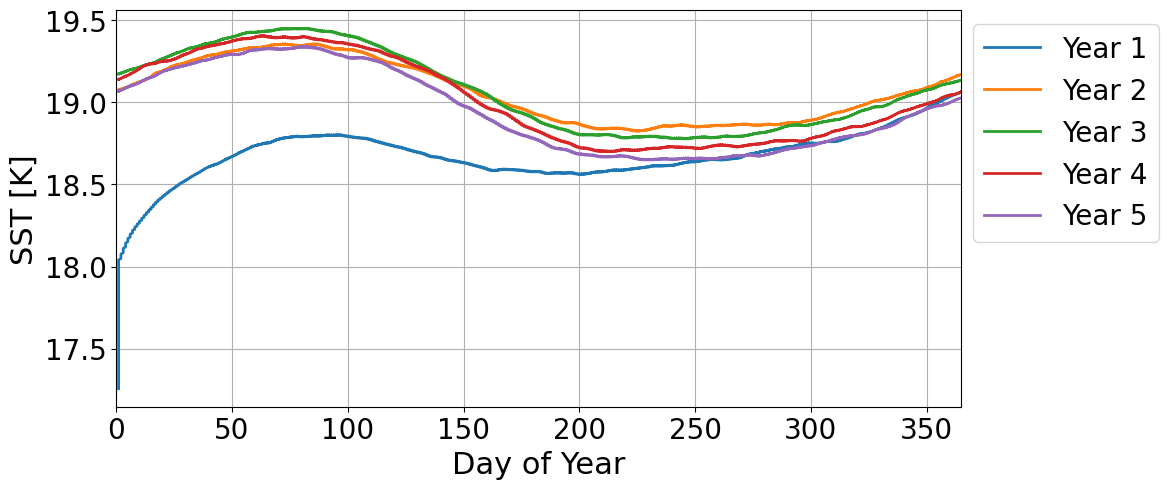

In [69]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, sst_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, sst_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, sst_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, sst_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, sst_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SST [K]", size = 22)
# plt.ylim(18,19.5)
plt.xlim(0,365)
plt.yticks(size=20)
plt.xticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [70]:
def sic_timeseries(ds):
    sic = ds["sic"]

    # Mask ice to be over threshold to count towards ice coverage
    ice_present = sic >= 0.15

    # Ocean fraction
    ocean_frac = 1.0 - ds["lsm"]

    # Latitude weights
    lat = sic["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, sic)


    # Numerator: ice area over the ocean
    num = (ice_present * ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [71]:
sic_year1 = sic_timeseries(year1)  # Array of SIC at each timestep
sic_year2 = sic_timeseries(year2)
sic_year3 = sic_timeseries(year3)
sic_year4 = sic_timeseries(year4)
sic_year5 = sic_timeseries(year5)

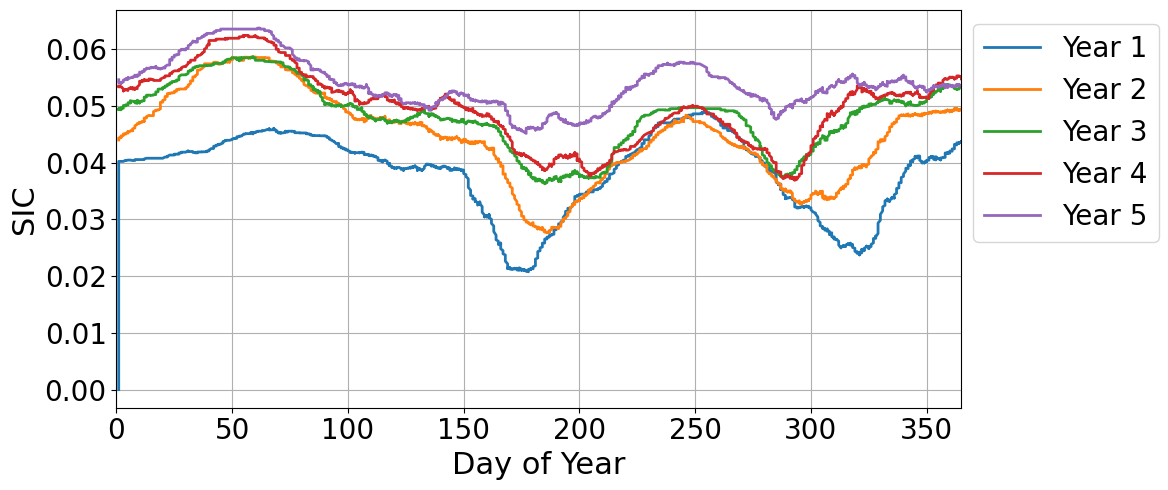

In [72]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, sic_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, sic_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, sic_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, sic_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, sic_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SIC", size = 22)
# plt.ylim(0,0.07)
plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
# plt.yticks([0,0.01,0.02,0.03,0.04,0.05,0.06,0.07],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [73]:
def st_timeseries(ds):
    st = ds["st"].isel(soil_layer=0)

    # Land mask
    land = ds["lsm"]

    # Latitude weights
    lat = st["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, st)

    # Numerator: ice area over the ocean
    num = (st * land * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (st * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [74]:
st_year1 = st_timeseries(year1)  # Array of SIC at each timestep
st_year2 = st_timeseries(year2)
st_year3 = st_timeseries(year3)
st_year4 = st_timeseries(year4)
st_year5 = st_timeseries(year5)

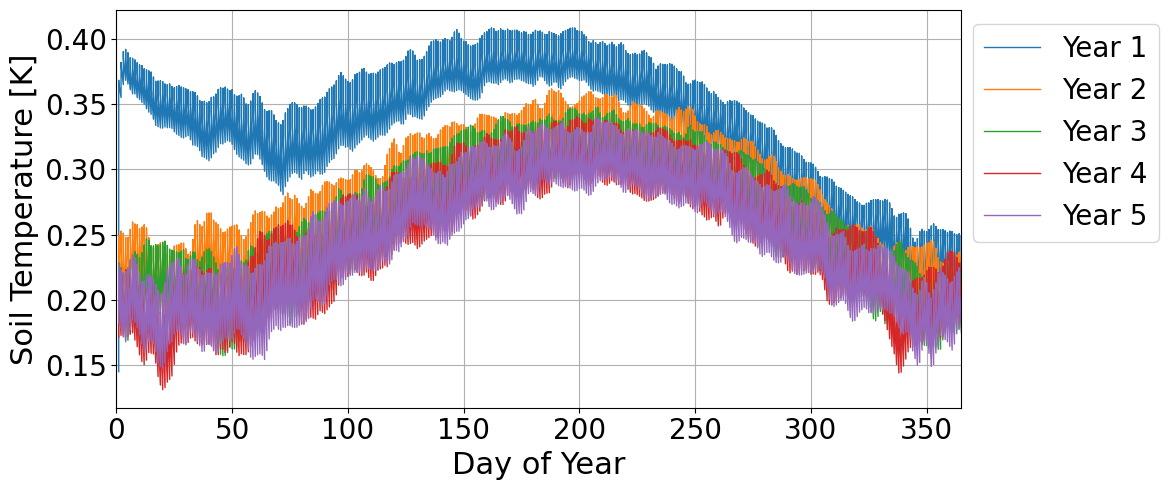

In [75]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, st_year1, label="Year 1", linewidth=1)
plt.plot(year2.time.dt.dayofyear.values, st_year2, label="Year 2", linewidth=1)
plt.plot(year3.time.dt.dayofyear.values, st_year3, label="Year 3", linewidth=1)
plt.plot(year4.time.dt.dayofyear.values, st_year4, label="Year 4", linewidth=1)
plt.plot(year5.time.dt.dayofyear.values, st_year5, label="Year 5", linewidth=1)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Soil Temperature [K]", size = 22)
# plt.ylim(18,19.5)
# plt.ylim(-5,5)
plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [76]:
def tsurf_timeseries(ds):
    tsurf = ds["tsurf"]

    # Latitude weights
    lat = tsurf["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, tsurf)

    # Numerator: ice area over the ocean
    num = (tsurf * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [77]:
tsurf_year1 = tsurf_timeseries(year1)  # Array of SIC at each timestep
tsurf_year2 = tsurf_timeseries(year2)
tsurf_year3 = tsurf_timeseries(year3)
tsurf_year4 = tsurf_timeseries(year4)
tsurf_year5 = tsurf_timeseries(year5)

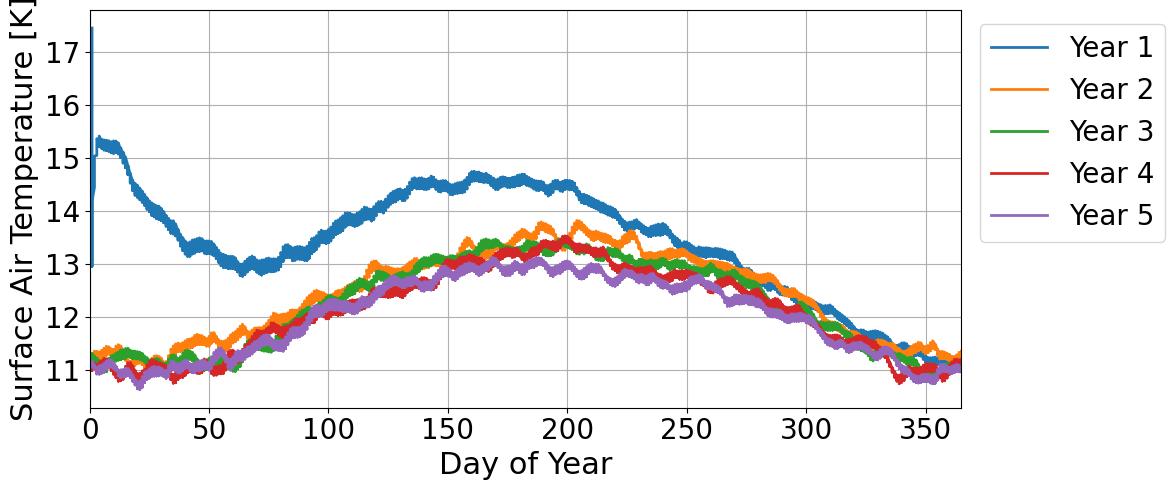

In [78]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, tsurf_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, tsurf_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, tsurf_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, tsurf_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, tsurf_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Surface Air Temperature [K]", size = 22)
# plt.ylim(10,16)
plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
# plt.yticks([10,11,12,13,14,15,16],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

Radiation budget stabilisation

In [79]:
# TOA Net Radiation

# TOA = SW_in - OLR - OSR
def toa_timeseries(ds):
    olr = ds["olr"]
    osr = ds["osr"]

    # OLR value
    lat_olr = olr["lat"]
    weights_olr = np.cos(np.deg2rad(lat_olr))
    weights_olr = weights_olr.where(np.isfinite(weights_olr), 0)
    weights_2d_olr, _ = xr.broadcast(weights_olr, olr)

    num_olr = (olr * weights_2d_olr).sum(dim=["lat", "lon"])
    den_olr = (weights_2d_olr).sum(dim=["lat", "lon"])
    result_olr = num_olr / den_olr.where(den_olr != 0, np.nan)
    olr_vals = result_olr.values

    # OSR value
    lat_osr = osr["lat"]
    weights_osr = np.cos(np.deg2rad(lat_osr))
    weights_osr = weights_osr.where(np.isfinite(weights_osr), 0)
    weights_2d_osr, _ = xr.broadcast(weights_osr, osr)

    num_osr = (osr * weights_2d_osr).sum(dim=["lat", "lon"])
    den_osr = (weights_2d_osr).sum(dim=["lat", "lon"])
    result_osr = num_osr / den_osr.where(den_osr != 0, np.nan)
    osr_vals = result_osr.values

    sw_in = 1365 * 1.25 / 4 

    toa = sw_in - result_olr - result_osr   
    
    return toa.values  # Return as numpy array

In [80]:
toa_year1 = toa_timeseries(year1)  # Array of SIC at each timestep
toa_year2 = toa_timeseries(year2)
toa_year3 = toa_timeseries(year3)
toa_year4 = toa_timeseries(year4)
toa_year5 = toa_timeseries(year5)

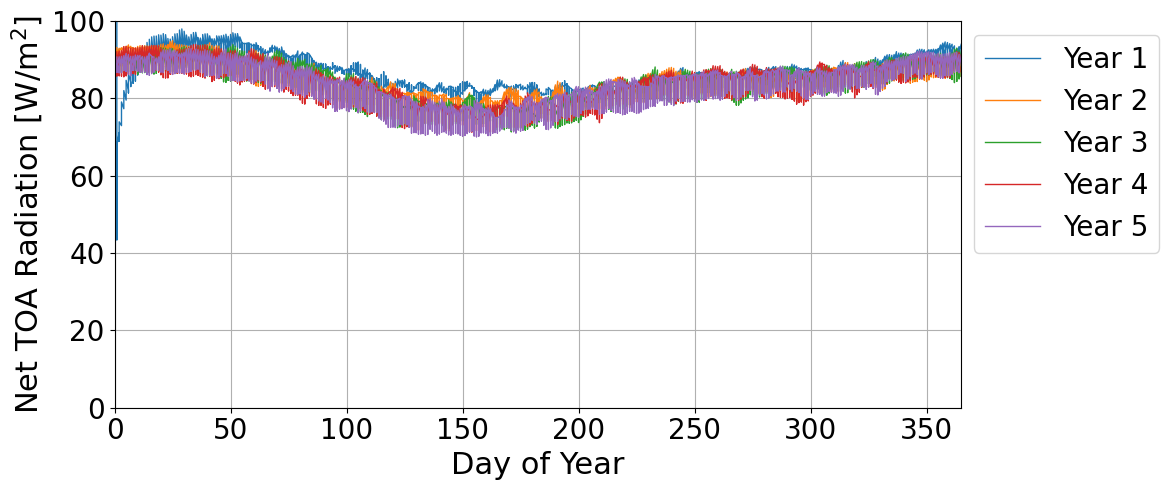

In [82]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, toa_year1, label="Year 1", linewidth=1)
plt.plot(year2.time.dt.dayofyear.values, toa_year2, label="Year 2", linewidth=1)
plt.plot(year3.time.dt.dayofyear.values, toa_year3, label="Year 3", linewidth=1)
plt.plot(year4.time.dt.dayofyear.values, toa_year4, label="Year 4", linewidth=1)
plt.plot(year5.time.dt.dayofyear.values, toa_year5, label="Year 5", linewidth=1)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Net TOA Radiation [W/m$^2$]", size = 22)
plt.ylim(0,100)
plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
# plt.yticks([10,11,12,13,14,15,16],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()